<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-house-purchase-decisions-eda-ml-100?scriptVersionId=265013906" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-house-purchase-decision-dataset/global_house_purchase_dataset.csv


## Title : Global House Purchase Decisions

## Description:
This dataset captures factors influencing house purchase decisions across different regions worldwide. It includes demographic, financial, and property-related features such as buyer age, income, employment status, property location, price, size, and amenities. The dataset can be used to analyze buying patterns, predict purchase likelihood, and build machine learning models for real estate market insights. It is suitable for research in housing trends, consumer behavior, and predictive analytics in real estate.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/global-house-purchase-decision-dataset/global_house_purchase_dataset.csv")

In [3]:
df.head()

,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,...,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,...,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,...,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,...,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,...,17676,65833,25,8965,33208,0.03,3,3,4,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   property_id              200000 non-null  int64  
 1   country                  200000 non-null  object 
 2   city                     200000 non-null  object 
 3   property_type            200000 non-null  object 
 4   furnishing_status        200000 non-null  object 
 5   property_size_sqft       200000 non-null  int64  
 6   price                    200000 non-null  int64  
 7   constructed_year         200000 non-null  int64  
 8   previous_owners          200000 non-null  int64  
 9   rooms                    200000 non-null  int64  
 10  bathrooms                200000 non-null  int64  
 11  garage                   200000 non-null  int64  
 12  garden                   200000 non-null  int64  
 13  crime_cases_reported     200000 non-null  int64  
 14  lega

In [5]:
df.tail()

,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
199995,199996,Germany,Berlin,Villa,Fully-Furnished,685,203328,1968,1,3,...,78330,104050,15,17670,99278,0.01,8,4,5,1
199996,199997,China,Shenzhen,Townhouse,Unfurnished,3818,1454627,1977,5,7,...,25400,1175297,20,2865,279330,0.34,7,10,9,1
199997,199998,Japan,Kyoto,Villa,Semi-Furnished,3603,1619147,1990,2,4,...,28220,743049,30,5595,876098,0.17,5,3,9,0
199998,199999,South Africa,Johannesburg,Apartment,Unfurnished,1706,306165,2010,0,4,...,12240,150774,15,16300,155391,0.11,6,10,6,0
199999,200000,Brazil,Rio de Janeiro,Apartment,Semi-Furnished,3652,732698,1986,0,1,...,22644,548714,30,5165,183984,0.15,6,4,9,0


In [6]:
df.describe()

,property_id,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,garage,garden,crime_cases_reported,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
count,200000.000000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,2.000000e+05,200000.000000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,3195.633460,1.215365e+06,1991.487770,3.001370,4.513855,2.760030,0.499350,0.500215,1.229065,...,46528.625830,7.597583e+05,19.986375,10559.693105,4.556068e+05,0.195387,5.498650,5.505240,5.495615,0.230340
std,57735.171256,1613.322287,8.236633e+05,18.494064,2.002198,2.295669,1.840959,0.500001,0.500001,1.185336,...,27997.353766,5.489401e+05,7.081080,5427.241879,3.629865e+05,0.219689,2.875361,2.870945,2.870206,0.421052
min,1.000000,400.000000,5.628800e+04,1960.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,2000.000000,2.350400e+04,10.000000,500.000000,8.966000e+03,0.000000,1.000000,1.000000,1.000000,0.000000
25%,50000.750000,1802.000000,5.659895e+05,1975.000000,1.000000,3.000000,1.000000,0.000000,0.000000,0.000000,...,21450.000000,3.372802e+05,15.000000,5770.000000,1.849592e+05,0.070000,3.000000,3.000000,3.000000,0.000000
50%,100000.500000,3190.000000,1.023429e+06,1991.000000,3.000000,5.000000,2.000000,0.000000,1.000000,1.000000,...,41465.000000,6.269325e+05,20.000000,10520.000000,3.561700e+05,0.130000,5.000000,5.000000,5.000000,0.000000
75%,150000.250000,4589.000000,1.725556e+06,2008.000000,5.000000,7.000000,4.000000,1.000000,1.000000,2.000000,...,70805.000000,1.058416e+06,25.000000,15260.000000,6.257352e+05,0.240000,8.000000,8.000000,8.000000,0.000000
max,200000.000000,6000.000000,4.202732e+06,2023.000000,6.000000,8.000000,8.000000,1.000000,1.000000,10.000000,...,100000.000000,3.520150e+06,30.000000,20000.000000,2.492723e+06,3.460000,10.000000,10.000000,10.000000,1.000000


In [7]:
df.nunique()

property_id                200000
country                        13
city                           40
property_type                   6
furnishing_status               3
property_size_sqft           5601
price                      192130
constructed_year               64
previous_owners                 7
rooms                           8
bathrooms                       8
garage                          2
garden                          2
crime_cases_reported           11
legal_cases_on_property         2
customer_salary             36020
loan_amount                187684
loan_tenure_years               5
monthly_expenses             6655
down_payment               180244
emi_to_income_ratio           266
satisfaction_score             10
neighbourhood_rating           10
connectivity_score             10
decision                        2
dtype: int64

In [8]:
df.isnull().sum()

property_id                0
country                    0
city                       0
property_type              0
furnishing_status          0
property_size_sqft         0
price                      0
constructed_year           0
previous_owners            0
rooms                      0
bathrooms                  0
garage                     0
garden                     0
crime_cases_reported       0
legal_cases_on_property    0
customer_salary            0
loan_amount                0
loan_tenure_years          0
monthly_expenses           0
down_payment               0
emi_to_income_ratio        0
satisfaction_score         0
neighbourhood_rating       0
connectivity_score         0
decision                   0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

property_id                  int64
country                     object
city                        object
property_type               object
furnishing_status           object
property_size_sqft           int64
price                        int64
constructed_year             int64
previous_owners              int64
rooms                        int64
bathrooms                    int64
garage                       int64
garden                       int64
crime_cases_reported         int64
legal_cases_on_property      int64
customer_salary              int64
loan_amount                  int64
loan_tenure_years            int64
monthly_expenses             int64
down_payment                 int64
emi_to_income_ratio        float64
satisfaction_score           int64
neighbourhood_rating         int64
connectivity_score           int64
decision                     int64
dtype: object

In [11]:
df.shape

(200000, 25)

In [12]:
df.describe().loc[['min','min', "max"]]

,property_id,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,garage,garden,crime_cases_reported,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
min,1.0,400.0,56288.0,1960.0,0.0,1.0,1.0,0.0,0.0,0.0,...,2000.0,23504.0,10.0,500.0,8966.0,0.00,1.0,1.0,1.0,0.0
min,1.0,400.0,56288.0,1960.0,0.0,1.0,1.0,0.0,0.0,0.0,...,2000.0,23504.0,10.0,500.0,8966.0,0.00,1.0,1.0,1.0,0.0
max,200000.0,6000.0,4202732.0,2023.0,6.0,8.0,8.0,1.0,1.0,10.0,...,100000.0,3520150.0,30.0,20000.0,2492723.0,3.46,10.0,10.0,10.0,1.0


In [13]:
df.columns

Index(['property_id', 'country', 'city', 'property_type', 'furnishing_status',
       'property_size_sqft', 'price', 'constructed_year', 'previous_owners',
       'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported',
       'legal_cases_on_property', 'customer_salary', 'loan_amount',
       'loan_tenure_years', 'monthly_expenses', 'down_payment',
       'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating',
       'connectivity_score', 'decision'],
      dtype='object')

## DAta visualizations

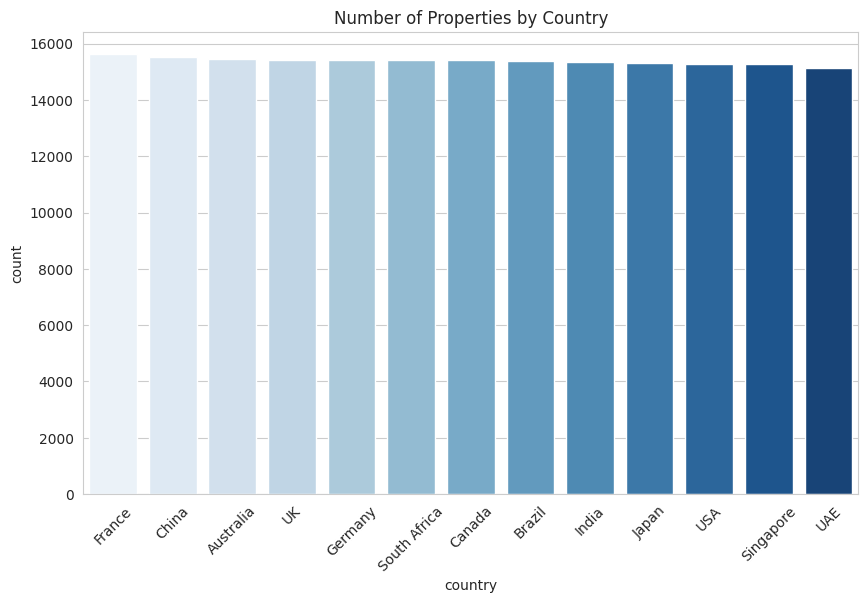

In [14]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# 1. Count of properties by country
plt.figure()
sns.countplot(data=df, x='country', order=df['country'].value_counts().index, palette='Blues')
plt.title("Number of Properties by Country")
plt.xticks(rotation=45)
plt.show()

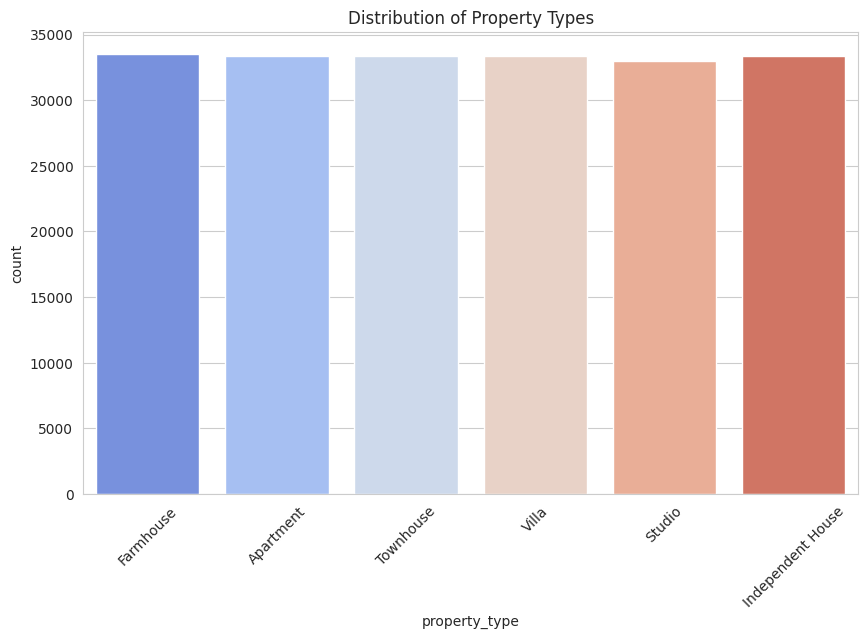

In [15]:
# 2. Property type distribution
plt.figure()
sns.countplot(data=df, x='property_type', palette='coolwarm')
plt.title("Distribution of Property Types")
plt.xticks(rotation=45)
plt.show()

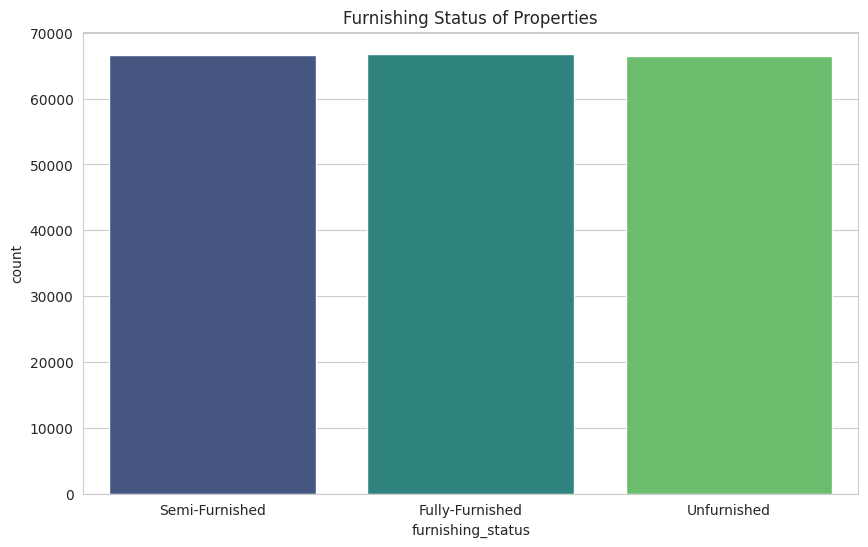

In [16]:
# 3. Furnishing status distribution
plt.figure()
sns.countplot(data=df, x='furnishing_status', palette='viridis')
plt.title("Furnishing Status of Properties")
plt.show()

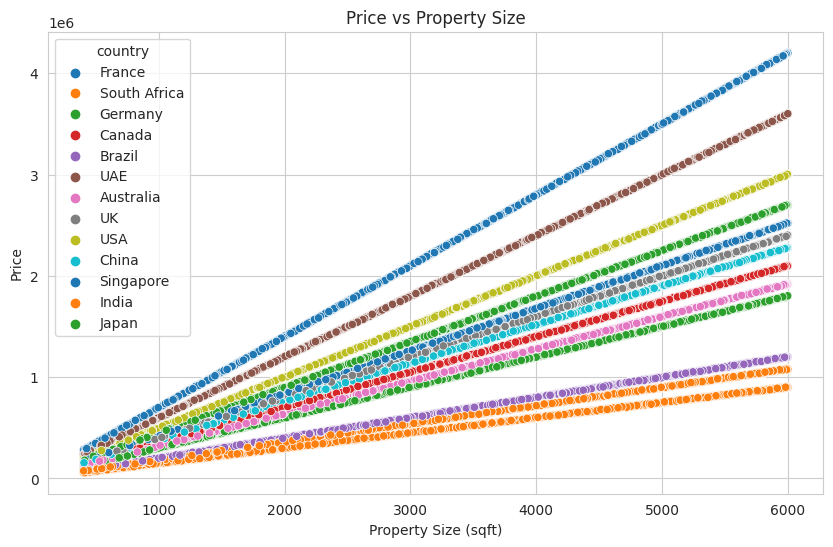

In [17]:
# 4. Price vs Property Size
plt.figure()
sns.scatterplot(data=df, x='property_size_sqft', y='price', hue='country', palette='tab10')
plt.title("Price vs Property Size")
plt.xlabel("Property Size (sqft)")
plt.ylabel("Price")
plt.show()

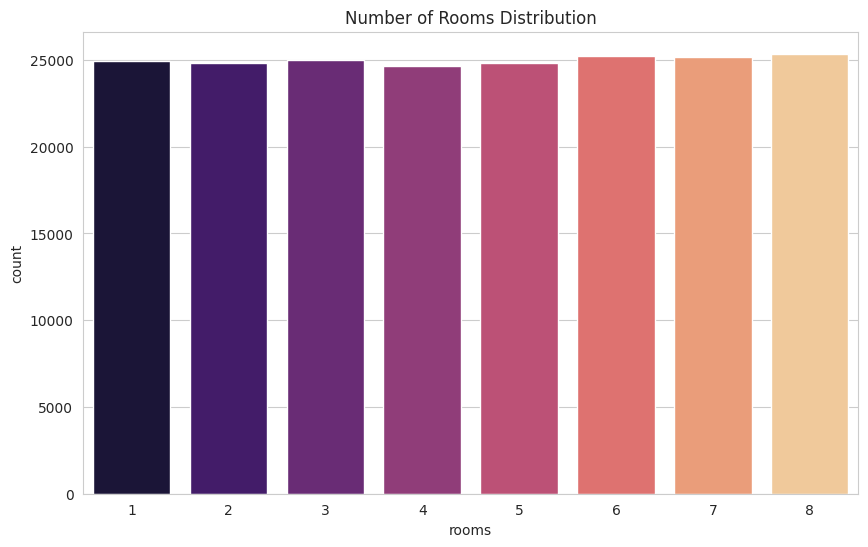

In [18]:
# 5. Distribution of rooms
plt.figure()
sns.countplot(data=df, x='rooms', palette='magma')
plt.title("Number of Rooms Distribution")
plt.show()


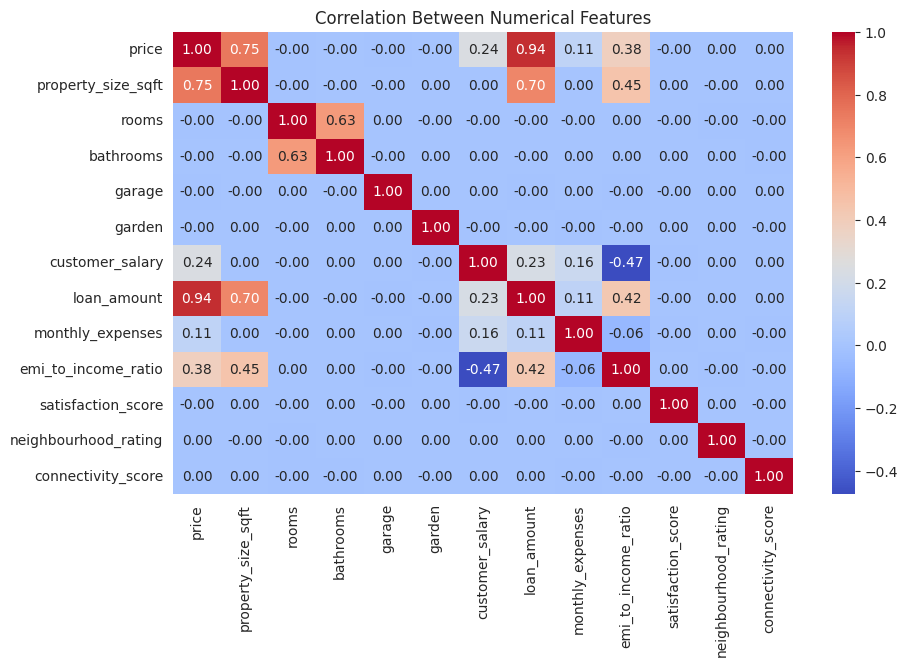

In [19]:
# 6. Correlation heatmap
plt.figure()
corr = df[['price', 'property_size_sqft', 'rooms', 'bathrooms', 'garage', 
           'garden', 'customer_salary', 'loan_amount', 'monthly_expenses', 
           'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 
           'connectivity_score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.show()

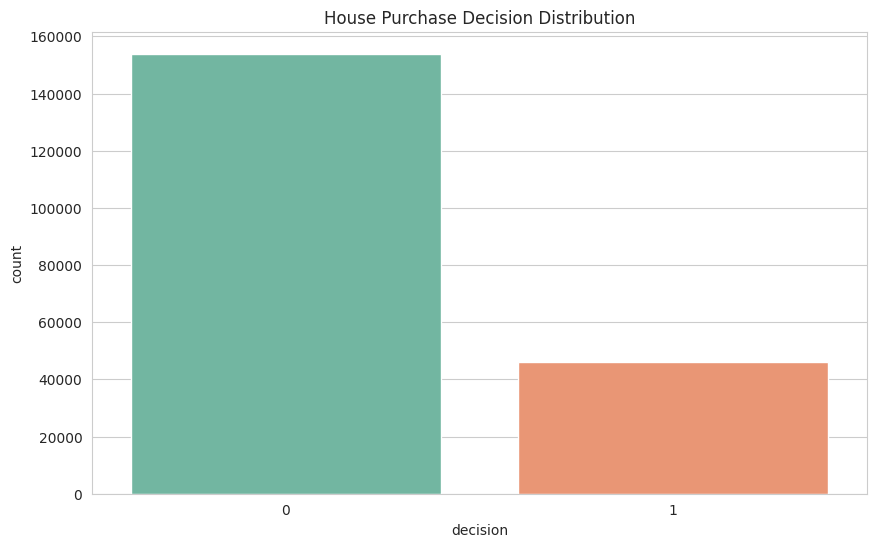

In [20]:
# 7. Decision distribution (Buy / Not Buy)
plt.figure()
sns.countplot(data=df, x='decision', palette='Set2')
plt.title("House Purchase Decision Distribution")
plt.show()

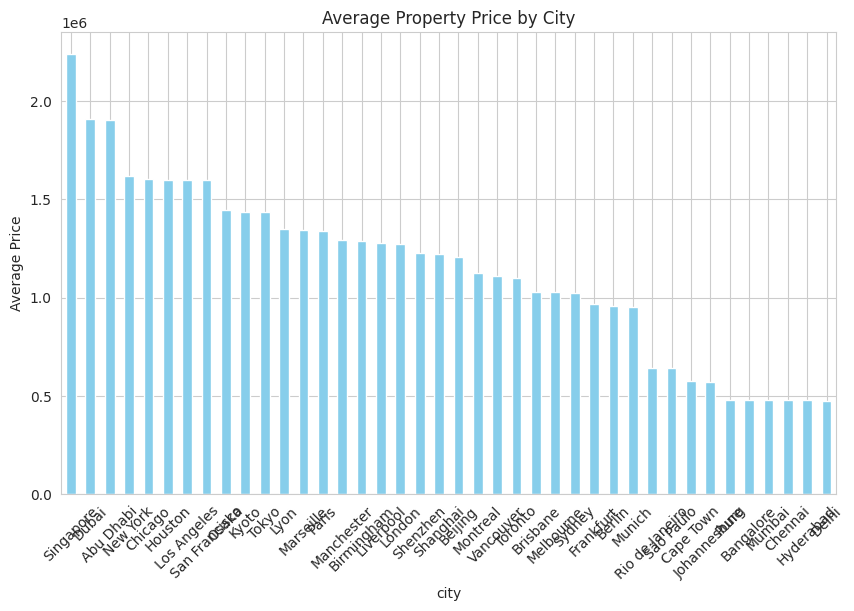

In [21]:
# 8. Average price by city
plt.figure()
avg_price_city = df.groupby('city')['price'].mean().sort_values(ascending=False)
avg_price_city.plot(kind='bar', color='skyblue')
plt.title("Average Property Price by City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

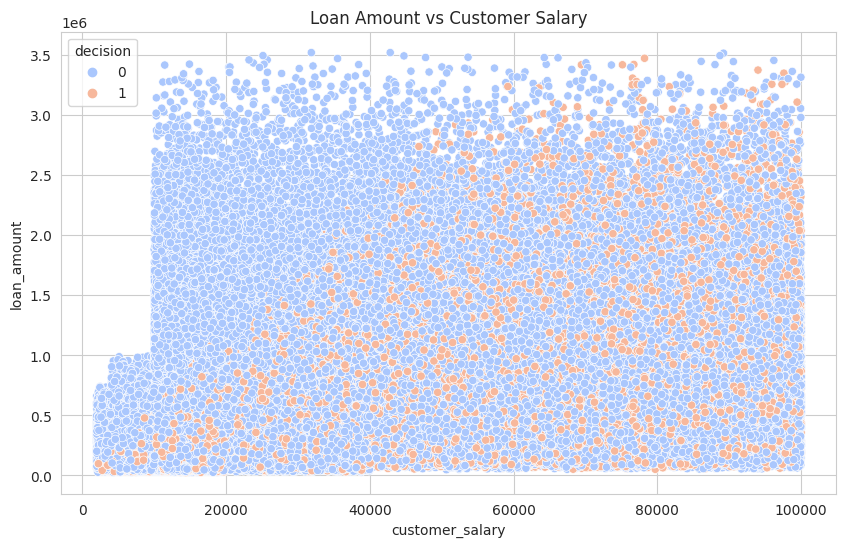

In [22]:
# 9. Loan amount vs Customer Salary
plt.figure()
sns.scatterplot(data=df, x='customer_salary', y='loan_amount', hue='decision', palette='coolwarm')
plt.title("Loan Amount vs Customer Salary")
plt.show()

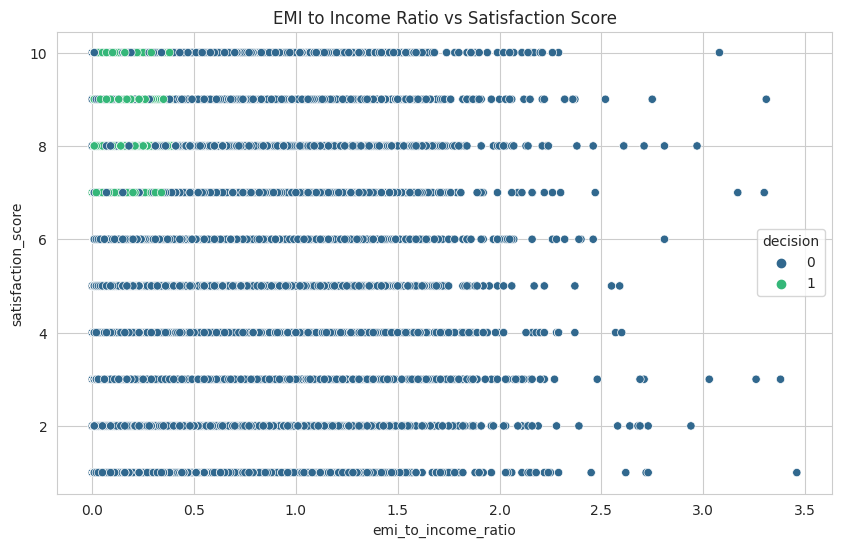

In [23]:
# 10. EMI to Income Ratio vs Satisfaction Score
plt.figure()
sns.scatterplot(data=df, x='emi_to_income_ratio', y='satisfaction_score', hue='decision', palette='viridis')
plt.title("EMI to Income Ratio vs Satisfaction Score")
plt.show()

## ML Algorithms

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [25]:
# Check column names
print(df.columns.tolist())

['property_id', 'country', 'city', 'property_type', 'furnishing_status', 'property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 'connectivity_score', 'decision']


In [26]:
categorical_cols = ['country', 'city', 'property_type', 'furnishing_status']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [27]:
df['decision'] = le.fit_transform(df['decision'])

# Features and target
X = df.drop(['property_id', 'decision'], axis=1)
y = df['decision']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [31]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 94.28%
Decision Tree Accuracy: 100.00%
Random Forest Accuracy: 100.00%
Gradient Boosting Accuracy: 100.00%
SVM Accuracy: 99.11%
KNN Accuracy: 92.11%
Naive Bayes Accuracy: 73.86%


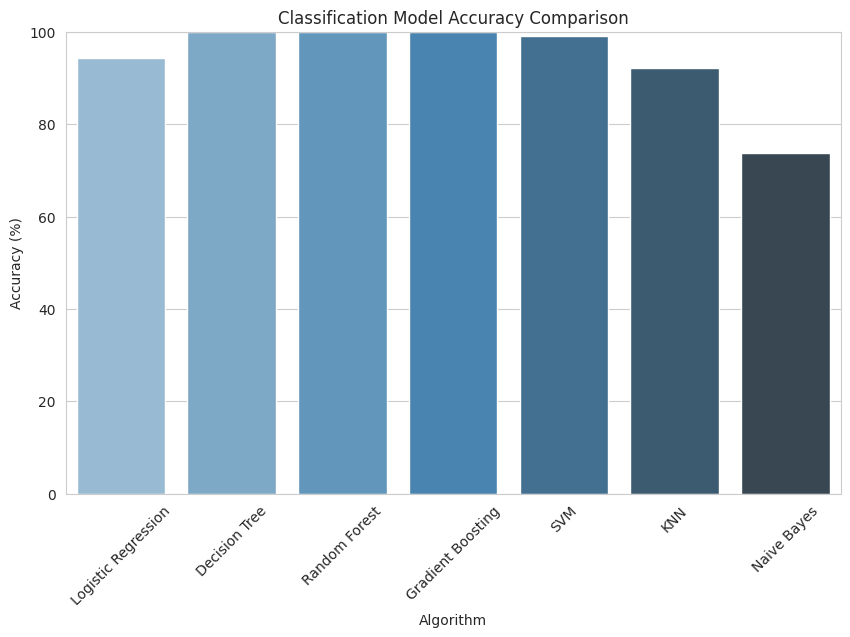

In [32]:
results_df = pd.DataFrame(list(results.items()), columns=["Algorithm", "Accuracy (%)"])

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x="Algorithm", y="Accuracy (%)", data=results_df, palette="Blues_d")
plt.title("Classification Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.show()

## thank you..pls upvote!!!!!